In [1]:
import os, yaml, sys
import numpy as np
import matplotlib.pyplot as plt
import h5py
from IPython.display import clear_output
import random
ENV = os.getenv("MY_ENV", "dev")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
sys.path.append(paths["useful_stuff_path"])
from useful_stuff.general_utils.utils import TimeSeries, print_wise, get_lagplot
from useful_stuff.general_utils.RSA import dRSA
from useful_stuff.general_utils.regression import dyn_linear_encoding
from useful_stuff.general_utils.II import dynInformationImbalance
from project_specific_utils.dataloader import load_meg_data
from image_processing.gaze_dep_models import save_pixelwise_luminance, save_OF


In [28]:
from dataclasses import dataclass, field

@dataclass
class Cfg:
    sub_num = 3
    run = 1
    neu_fs = 100
    mod_fs = 23.976
    model_name = "pixelwise_lum";
    sq_side = 250
    downsampled_sq_size = 50
    sensors_group = 'front'
    model_name = "pixelwise_luminance"
    time_points = 50
    pseudotrials_n = 500
    max_lag=30
cfg = Cfg()

In [29]:
neu_rep1, labels1 = load_meg_data(paths, cfg.sub_num, cfg.run, cfg.sensors_group, cfg.neu_fs)
neu_rep2, labels2 = load_meg_data(paths, cfg.sub_num, cfg.run+3, cfg.sensors_group, cfg.neu_fs)

In [30]:
pixelwise_filename = save_pixelwise_luminance(paths, "pixelwise_luminance", cfg.sub_num, cfg.run, 24, cfg.sq_side, *(cfg.downsampled_sq_size,))
with h5py.File(pixelwise_filename, "r") as f:
    pl = f['vecrep'][:]
    pixelwise_mod = TimeSeries(f['vecrep'][:], cfg.mod_fs)
    pixelwise_mod.resample(cfg.neu_fs)
eyeOF_filename = save_OF(paths, 'eyeOF', cfg.sub_num, cfg.run, cfg.mod_fs, cfg.sq_side, *(cfg.downsampled_sq_size,))
with h5py.File(eyeOF_filename, "r") as f:
    eyeOF = f['vecrep'][:]
    eyeOF_mod = TimeSeries(f['vecrep'][:], cfg.mod_fs)
    eyeOF_mod.resample(cfg.neu_fs)
OF_filename = save_OF(paths, 'OFdir', cfg.sub_num, cfg.run, cfg.mod_fs, cfg.sq_side, *(cfg.downsampled_sq_size,))
with h5py.File(OF_filename, "r") as f:
    OF = f['vecrep'][:]
    OF_mod = TimeSeries(f['vecrep'][:], cfg.mod_fs)
    OF_mod.resample(cfg.neu_fs)


In [31]:
OF.shape

(5000, 20950)

In [32]:
import numpy as np

mask = ~np.isfinite(OF)
OF[mask] = 0

In [33]:
from sklearn.decomposition import PCA

pca = PCA(n_components=100)
X_reduced = pca.fit_transform(OF.T)

In [34]:
pixelwise_mod = TimeSeries(X_reduced.T, cfg.mod_fs)
pixelwise_mod.resample(cfg.neu_fs)

In [35]:
pixelwise_mod.get_array().shape

(100, 87379)

In [36]:
pseudotrials_idx = random.sample(range(len(pixelwise_mod)- cfg.time_points), cfg.pseudotrials_n)
X = []; Y = []
for i_pst in pseudotrials_idx:
    X.append(pixelwise_mod[i_pst:i_pst+cfg.time_points])
    Y.append(neu_rep1[i_pst:i_pst+cfg.time_points][:10,:])
    
X = TimeSeries(np.stack(X, axis=2), cfg.mod_fs)
Y = TimeSeries(np.stack(Y, axis=2), neu_rep1.get_fs())

In [37]:
print(X.get_array().shape)
print(Y.get_array().shape)

(100, 50, 500)
(10, 50, 500)


In [38]:
X = TimeSeries(pixelwise_mod.get_array()[:,:,np.newaxis], neu_rep1.get_fs())
Y = TimeSeries(neu_rep1.get_array()[:,:len(pixelwise_mod),np.newaxis], neu_rep1.get_fs())

In [39]:
model = dyn_linear_encoding('ridge', 'kf', cfg.max_lag, score_type="r2")
X.z_score_feats()
Y.z_score_feats()
s = model.crossvalidate_general_dyn(X, Y)

Text(0.5, 1.0, 'front')

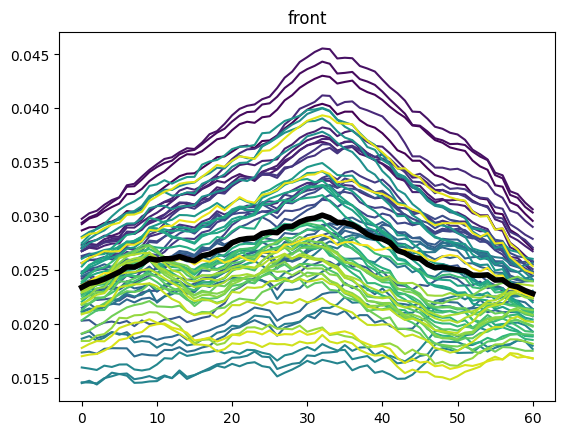

In [40]:
import matplotlib.pyplot as plt
import numpy as np

data = s.get_array()
n_lines = data.shape[0]

cmap = plt.get_cmap("viridis")  # choose your cmap

for i in range(n_lines):
    color = cmap(i / n_lines)
    plt.plot(data.T[:, i], color=color, label=labels1[i])

# mean in black (on top)
plt.plot(data.mean(axis=0), linewidth=4, color="k")
plt.title(cfg.sensors_group)

# plt.legend(fontsize=6)